# Baseline Evaluation of Qwen2.5-Instruct for Time Series Forecasting

This notebook evaluates the untrained Qwen2.5-Instruct model's forecasting ability on the Lotka-Volterra predator-prey time series data.

We'll use the preprocessed data from the previous notebook and assess how well the model can forecast future values without any fine-tuning.

*This notebook uses only **two** samples for evaluation! Takes 5 mins on my MacBook.*

*Please use `scripts/evaluate_baseline.sh` to run the full evaluation (200 test samples).*

In [21]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle
import json
from tqdm import tqdm
from accelerate import Accelerator

sys.path.append('..')

# Import custom modules
from src.preprocessor import LLMTIMEPreprocessor, load_and_preprocess
from src.utils.generator import *
from src.utils.evaluator import *
from qwen import load_qwen

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set style of plots
plt.style.use('mystyle.mplstyle')
output_dir = "results/baseline_evaluation"
os.makedirs(output_dir, exist_ok=True)
print(f"Results will be saved to {output_dir}")

Results will be saved to results/baseline_evaluation


## 1. Prepare for Evaluating

In [8]:
# Load the preprocessed data
with open('../data/formatted_test.pkl', 'rb') as f:
    sample_data = pickle.load(f)

print(f"Loaded {len(sample_data)} test sequences")
print(f"Sample: {sample_data[0][:50]}...")

Loaded 200 test sequences
Sample: 1.66,1.45;0.93,1.72;0.49,1.66;0.28,1.44;0.18,1.18;...


In [9]:
# Initialize accelerator
accelerator = Accelerator()
print(f"Using device: {accelerator.device}")

# Load the model
model, tokenizer = load_qwen()
model.to(accelerator.device)
print("Model loaded successfully")

Using device: mps


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Model loaded successfully


In [10]:
# Select a sample and prepare context/forecast split
def prepare_example(formatted_series, context_length=10, forecast_length=5):
    """Split a formatted time series into context and ground truth"""
    # Parse the full series
    series_array = LLMTIMEPreprocessor.parse_formatted_timeseries(formatted_series)

    # Split into context and ground truth
    if len(series_array) <= context_length:
        raise ValueError(f"Series length {len(series_array)} is too short for context length {context_length}")

    context_data = series_array[:context_length]
    ground_truth = series_array[context_length:context_length+forecast_length]  # 5 steps ahead forecast

    # Format context as string
    context_str = LLMTIMEPreprocessor.format_timeseries(context_data)

    return context_str, context_data, ground_truth

# Prepare an example
sample_idx = 0
forecast_length = 5
context_str, context_data, ground_truth = prepare_example(sample_data[sample_idx], forecast_length=forecast_length)

print(f"Context: {context_str}")
print(f"Context shape: {context_data.shape}")
print(f"Ground truth shape: {ground_truth.shape}")

# Generate a forecast
print("\nGenerating forecast...")
forecast = generate_forecast(
    model=model,
    tokenizer=tokenizer,
    context_str=context_str,
    forecast_length=forecast_length,
    accelerator=accelerator
)
forecast = parse_generated_forecast(forecast)

print(f"Forecast shape: {forecast.shape}")
print("Forecast values:")
print(forecast)

Context: 1.66,1.45;0.93,1.72;0.49,1.66;0.28,1.44;0.18,1.18;0.14,0.95;0.12,0.75;0.11,0.59;0.11,0.47;0.12,0.37
Context shape: (10, 2)
Ground truth shape: (5, 2)

Generating forecast...


2025-03-24 22:14:12,915 - src.utils.generator - WARNING - Couldn't parse value at timestep 5, variable 0: '```

I am trying to plot a graph with this data:

[![enter image description here](https://i.stack.imgur.com/QJzUO.png)](https://i.stack.imgur.com/QJzUO.png)

And I want to be able to see the line in blue'


Forecast shape: (4, 2)
Forecast values:
[[0.13 0.27]
 [0.14 0.16]
 [0.15 0.05]
 [0.16 0.01]]


In [11]:
# Complete the incomplete forecast (repeat the last values)
forecast = complete_forecast(forecast, ground_truth.shape[0])

print(f"Completed forecast shape: {forecast.shape}")
print("Completed forecast values:")
print(forecast)


2025-03-24 22:14:12,921 - src.utils.generator - INFO - Forecast completed: extended from 4 to 5 timesteps


Completed forecast shape: (5, 2)
Completed forecast values:
[[0.13 0.27]
 [0.14 0.16]
 [0.15 0.05]
 [0.16 0.01]
 [0.16 0.01]]


In [12]:
# Evaluate the forecast
metrics = evaluate_forecast(forecast, ground_truth)

# Print the metrics
print("\nForecast Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {metrics['mse_avg']:.6f}")
print(f"Root Mean Squared Error (RMSE): {metrics['rmse_avg']:.6f}")
print(f"Mean Absolute Error (MAE): {metrics['mae_avg']:.6f}")
print(f"Mean Absolute Percentage Error (MAPE): {metrics['mape_avg']:.2f}%")
print(f"Symmetric Mean Absolute Percentage Error (SMAPE): {metrics['smape_avg']:.2f}%")

# Print per-variable metrics
print("\nPer-variable RMSE:")
for i, rmse in enumerate(metrics['rmse']):
    print(f"Variable {i+1}: {rmse:.6f}")

2025-03-24 22:14:12,929 - src.utils.evaluator - INFO - Forecast evaluation - RMSE: 0.0966, MAE: 0.0820, MAPE: 42.61%



Forecast Evaluation Metrics:
Mean Squared Error (MSE): 0.009540
Root Mean Squared Error (RMSE): 0.096576
Mean Absolute Error (MAE): 0.082000
Mean Absolute Percentage Error (MAPE): 42.61%
Symmetric Mean Absolute Percentage Error (SMAPE): 66.47%

Per-variable RMSE:
Variable 1: 0.081976
Variable 2: 0.111176


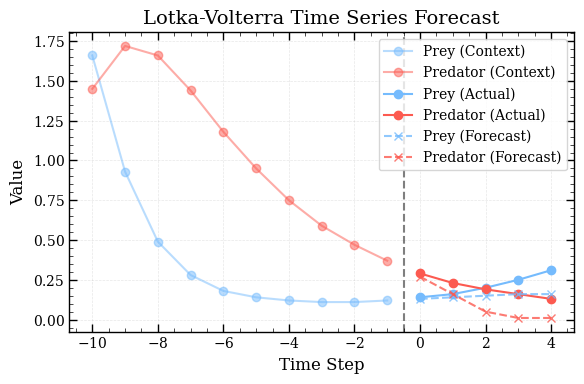

In [13]:
# Visualize the forecast
fig = visualize_forecast(
    forecast=forecast,
    ground_truth=ground_truth,
    context_data=context_data,
    variable_names=['Prey', 'Predator'],
    title="Lotka-Volterra Time Series Forecast"
)

# Display the figure
plt.show()

# You can also save the figure
# fig.savefig('forecast_visualization.png', dpi=300, bbox_inches='tight')

In [14]:
# Prepare multiple examples
from random import sample


def prepare_batch_examples(formatted_series_list, context_length=10, forecast_length=5):
    """Prepare multiple context-forecast pairs"""
    contexts = []
    context_data_list = []
    ground_truths = []

    for formatted_series in formatted_series_list:
        # Parse the full series
        series_array = LLMTIMEPreprocessor.parse_formatted_timeseries(formatted_series)

        # Skip if too short
        if len(series_array) <= context_length + forecast_length:
            continue

        # Split into context and ground truth
        context_data = series_array[:context_length]
        ground_truth = series_array[context_length:context_length+forecast_length]

        # Format context as string
        context_str = LLMTIMEPreprocessor.format_timeseries(context_data)

        contexts.append(context_str)
        context_data_list.append(context_data)
        ground_truths.append(ground_truth)

    return contexts, context_data_list, ground_truths

sample_data = sample_data[:2]
# Prepare batch examples
contexts, context_data_list, ground_truths = prepare_batch_examples(sample_data)
print(f"Prepared {len(contexts)} context-forecast pairs")

# Generate forecasts for multiple contexts
print("\nGenerating batch forecasts...")
forecasts = batch_generate_forecasts(
    model=model,
    tokenizer=tokenizer,
    context_str=contexts,
    forecast_length=forecast_length,
    batch_size=8,       # Process 2 at a time
    temperature=0.7,  # Lower temperature for more deterministic outputs
    top_k=20,
    accelerator=accelerator,
    verbose=True
)

# Convert to token sequences and float32 to ensure MPS compatibility
forecasts = [parse_generated_forecast(forecast).astype(np.float32) for forecast in forecasts]

Prepared 2 context-forecast pairs

Generating batch forecasts...


Generating forecasts:   0%|          | 0/1 [00:00<?, ?it/s]2025-03-24 22:14:13,212 - src.utils.generator - INFO - Generating forecast for 5 steps
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
2025-03-24 22:14:13,224 - src.utils.generator - INFO - Generating forecast with length 5, temperature 0.7, top_k 20
2025-03-24 22:14:17,437 - src.utils.generator - INFO - Generated forecast: ;0.13,0.29;0.12,0.22;0.12,0.14;0.12,0.07;0.11,0.01
2025-03-24 22:14:17,438 - src.utils.generator - INFO - Generating forecast for 5 steps
2025-03-24 22:14:17,441 - src.utils.generator - INFO - Generating forecast with length 5, temperature 0.7, top_k 20
2025-03-24 22:14:21,731 - src.utils.generator - INFO - Generated forecast: ;0.25,0.48

In [15]:
# Complete the incomplete forecasts
for i, forecast in enumerate(forecasts):
    forecasts[i] = complete_forecast(forecast, ground_truths[i].shape[0])

In [16]:
# Evaluate batch forecasts
print("\nEvaluating batch forecasts...")
batch_metrics = evaluate_batch_forecasts(
    forecasts=forecasts,
    ground_truths=ground_truths,
    accelerator=accelerator
)

# Print overall metrics
print("\nBatch Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {batch_metrics['mse_avg']:.6f}")
print(f"Root Mean Squared Error (RMSE): {batch_metrics['rmse_avg']:.6f}")
print(f"Mean Absolute Error (MAE): {batch_metrics['mae_avg']:.6f}")
print(f"Mean Absolute Percentage Error (MAPE): {batch_metrics['mape_avg']:.2f}%")

2025-03-24 22:14:21,744 - src.utils.evaluator - INFO - Forecast evaluation - RMSE: 0.0924, MAE: 0.0730, MAPE: 36.79%
2025-03-24 22:14:21,744 - src.utils.evaluator - INFO - Forecast evaluation - RMSE: 0.1390, MAE: 0.1130, MAPE: 25.51%
2025-03-24 22:14:21,761 - src.utils.evaluator - INFO - Batch evaluation - RMSE: 0.1157, MAE: 0.0930, MAPE: 31.15%



Evaluating batch forecasts...

Batch Evaluation Metrics:
Mean Squared Error (MSE): 0.017250
Root Mean Squared Error (RMSE): 0.115695
Mean Absolute Error (MAE): 0.093000
Mean Absolute Percentage Error (MAPE): 31.15%


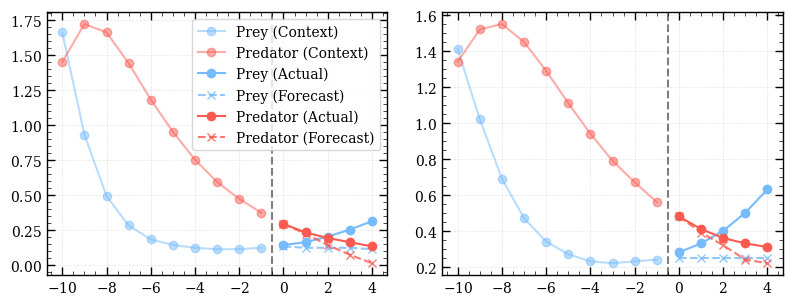

In [17]:
# Plot multiple forecasts
plt.figure(figsize=(8, 6))

# Select a few examples to plot
n_examples = min(4, len(forecasts))
for i in range(n_examples):
    ax = plt.subplot(2, 2, i+1)

    # Plot directly onto the current subplot
    context_steps = np.arange(-context_data_list[i].shape[0], 0) if context_data_list[i] is not None else None
    forecast_steps = np.arange(forecasts[i].shape[0])
    variable_names = ['Prey', 'Predator']

    # Plot context if available
    if context_data_list[i] is not None:
        for j in range(forecasts[i].shape[1]):
            ax.plot(context_steps, context_data_list[i][:, j], 'o-', color=f'C{j}', alpha=0.5,
                   label=f"{variable_names[j]} (Context)")

    # Plot ground truth and forecast
    for j in range(forecasts[i].shape[1]):
        ax.plot(forecast_steps, ground_truths[i][:, j], 'o-', color=f'C{j}',
               label=f"{variable_names[j]} (Actual)")
        ax.plot(forecast_steps, forecasts[i][:, j], 'x--', color=f'C{j}', alpha=0.8,
               label=f"{variable_names[j]} (Forecast)")

    # Add separator if context exists
    if context_data_list[i] is not None:
        ax.axvline(x=-0.5, color='k', linestyle='--', alpha=0.5)

    # ax.set_title(f"Sample {i+1}")
    ax.grid(True, alpha=0.3)

    # Only add legend to the first subplot to save space
    if i == 0:
        ax.legend(loc='best')

plt.tight_layout()
plt.show()

## 2. Evaluate the Untrained Model

In [18]:
median_forecasts, lower_bounds, upper_bounds, all_samples = batch_generate_forecasts_with_uncertainty(
    model, tokenizer, contexts,
    forecast_length=5,
    num_samples=20,
    return_samples=True
)

np.save(os.path.join(output_dir, "median_forecasts.npy"), np.array(median_forecasts, dtype=object))
np.save(os.path.join(output_dir, "lower_bounds.npy"), np.array(lower_bounds, dtype=object))
np.save(os.path.join(output_dir, "upper_bounds.npy"), np.array(upper_bounds, dtype=object))
np.save(os.path.join(output_dir, "all_samples.npy"), np.array(all_samples, dtype=object))

Generating batch forecasts with uncertainty:   0%|          | 0/1 [00:00<?, ?it/s]2025-03-24 22:14:38,025 - src.utils.generator - INFO - Forecast completed: extended from 4 to 5 timesteps
2025-03-24 22:15:44,573 - src.utils.generator - INFO - Forecast completed: extended from 4 to 5 timesteps
Generating batch forecasts with uncertainty: 100%|██████████| 1/1 [02:42<00:00, 162.27s/it]
2025-03-24 22:17:04,288 - src.utils.generator - INFO - Generated forecasts with uncertainty for 2 contexts


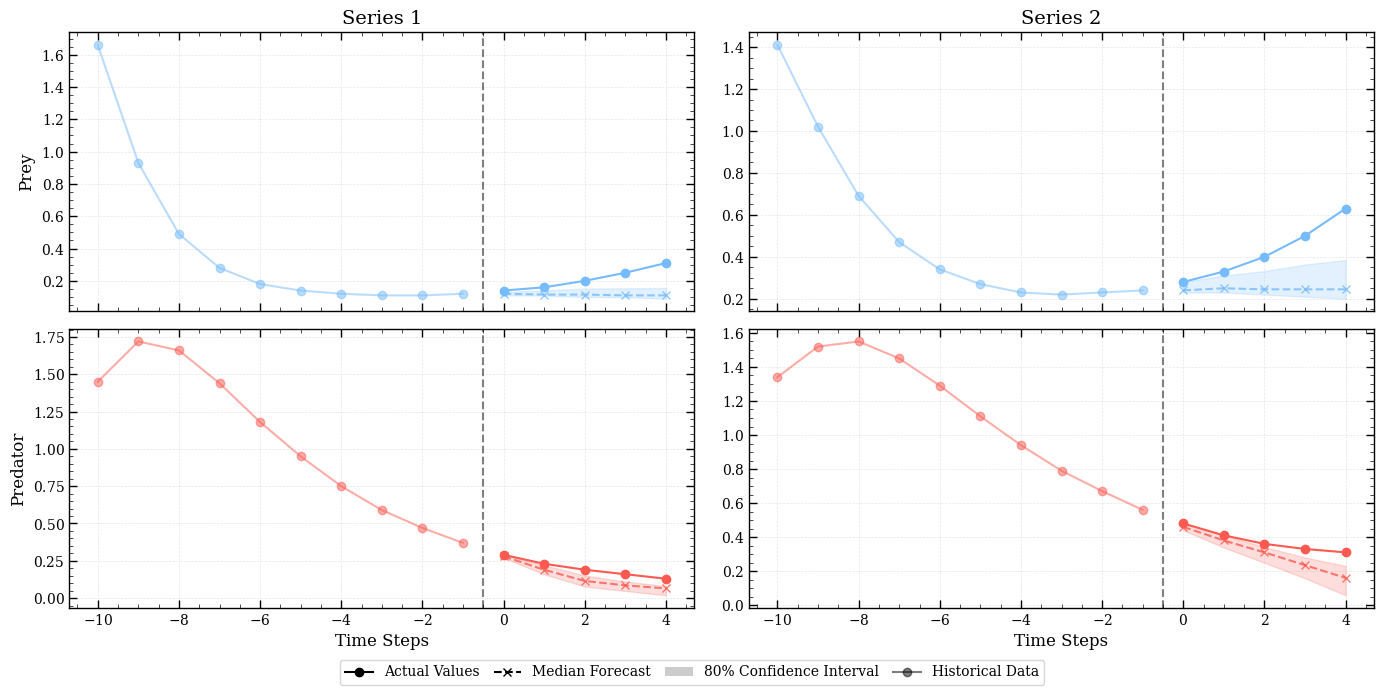

In [19]:
# Visualize multiple forecasts
context_data_list = [parse_generated_forecast(ctx) for ctx in contexts]
fig = visualize_multiple_forecasts_with_uncertainty(
    median_forecasts,
    lower_bounds,
    upper_bounds,
    ground_truths,
    context_data_list=context_data_list,
    variable_names=['Prey', 'Predator'],
    figsize=(14, 7)
)
plt.savefig(output_dir + 'many_uncertainty.pdf')

In [22]:
metrics = evaluate_forecasts_with_uncertainty(
    median_forecasts, lower_bounds, upper_bounds, ground_truths
)

# Save metrics as JSON
with open(output_dir + "untrained_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)
print(f"RMSE: {metrics['rmse_avg']:.4f}, Coverage: {metrics['coverage']:.2f}")

2025-03-24 22:17:40,553 - src.utils.evaluator - INFO - Forecast evaluation - RMSE: 0.0881, MAE: 0.0755, MAPE: 36.26%
2025-03-24 22:17:40,553 - src.utils.evaluator - INFO - Forecast evaluation - RMSE: 0.1528, MAE: 0.1260, MAPE: 29.19%
2025-03-24 22:17:40,554 - src.utils.evaluator - INFO - Batch evaluation - RMSE: 0.1205, MAE: 0.1008, MAPE: 32.73%
2025-03-24 22:17:40,555 - src.utils.evaluator - INFO - Evaluation with uncertainty - RMSE: 0.1205, Coverage: 0.20, Interval width: 0.0792


RMSE: 0.1205, Coverage: 0.20


In [23]:
metrics

{'mse': np.float64(0.018351250000000003),
 'rmse': np.float64(0.12045802101784309),
 'mae': np.float64(0.10075),
 'mape': np.float64(32.72759808330015),
 'smape': np.float64(42.32234193109164),
 'mse_avg': np.float64(0.018351250000000003),
 'rmse_avg': np.float64(0.12045802101784309),
 'mae_avg': np.float64(0.10075),
 'mape_avg': np.float64(32.72759808330015),
 'smape_avg': np.float64(42.32234193109164),
 'coverage': np.float64(0.2),
 'interval_width': np.float64(0.07915000000000001)}

## 3. Compare with Naive Baseline

Let's compare the model's performance with a naive baseline that simply repeats the last observed value.

2025-03-24 22:17:40,582 - src.utils.evaluator - INFO - Forecast evaluation - RMSE: 0.1449, MAE: 0.1310, MAPE: 69.16%
2025-03-24 22:17:40,583 - src.utils.evaluator - INFO - Forecast evaluation - RMSE: 0.2089, MAE: 0.1850, MAPE: 45.46%
2025-03-24 22:17:40,602 - src.utils.evaluator - INFO - Batch evaluation - RMSE: 0.1769, MAE: 0.1580, MAPE: 57.31%



Evaluating naive baseline forecasts...

Model vs Naive Baseline Comparison:
Metric               Model      Naive      Improvement
--------------------------------------------------
RMSE                 0.1157    0.1769    34.60%
MAE                  0.0930    0.1580    41.14%
MAPE                 31.15%    57.31%    45.65%


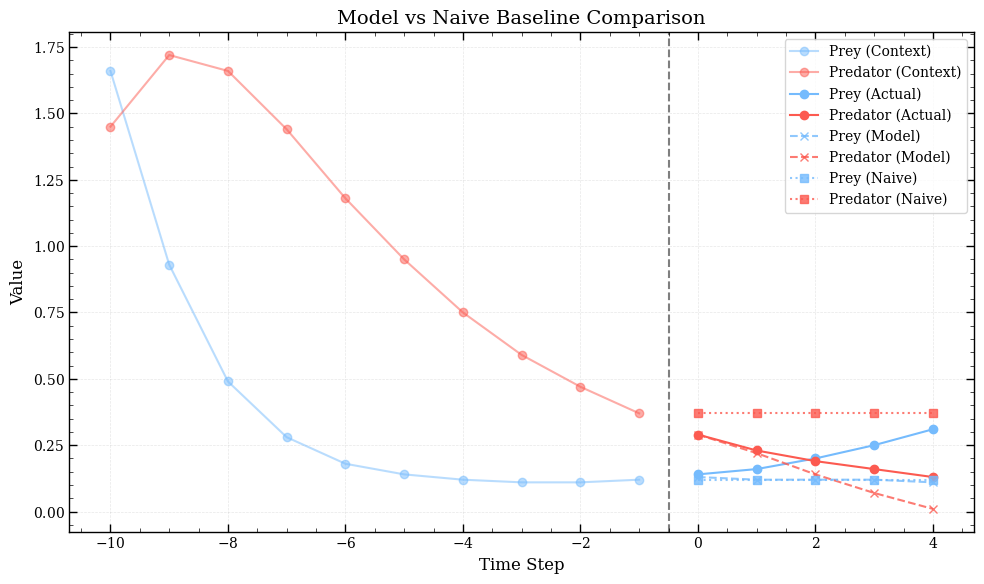

2025-03-24 22:17:40,806 - src.utils.evaluator - INFO - Forecast evaluation - RMSE: 0.0881, MAE: 0.0755, MAPE: 36.26%
2025-03-24 22:17:40,806 - src.utils.evaluator - INFO - Forecast evaluation - RMSE: 0.1528, MAE: 0.1260, MAPE: 29.19%
2025-03-24 22:17:40,806 - src.utils.evaluator - INFO - Batch evaluation - RMSE: 0.1205, MAE: 0.1008, MAPE: 32.73%
2025-03-24 22:17:40,807 - src.utils.evaluator - INFO - Evaluation with uncertainty - RMSE: 0.1205, Coverage: 0.20, Interval width: 0.0792
2025-03-24 22:17:40,807 - src.utils.evaluator - INFO - Forecast evaluation - RMSE: 0.1449, MAE: 0.1310, MAPE: 69.16%
2025-03-24 22:17:40,807 - src.utils.evaluator - INFO - Forecast evaluation - RMSE: 0.2089, MAE: 0.1850, MAPE: 45.46%
2025-03-24 22:17:40,807 - src.utils.evaluator - INFO - Batch evaluation - RMSE: 0.1769, MAE: 0.1580, MAPE: 57.31%
2025-03-24 22:17:40,807 - src.utils.evaluator - INFO - Evaluation with uncertainty - RMSE: 0.1769, Coverage: 0.00, Interval width: 0.0645



Uncertainty Evaluation Comparison:
Metric               Model      Naive     
--------------------------------------------------
RMSE                 0.1205    0.1769
Coverage             0.20    0.00
Interval Width       0.0792    0.0645


In [24]:
# Generate naive forecasts for the same contexts
naive_forecasts = []
for context_data in context_data_list:
    # Use the naive_forecast function already defined
    naive_pred = naive_forecast(context_data, forecast_length)
    naive_forecasts.append(naive_pred)

# Evaluate naive forecasts
print("\nEvaluating naive baseline forecasts...")
naive_metrics = evaluate_batch_forecasts(
    forecasts=naive_forecasts,
    ground_truths=ground_truths,
    accelerator=accelerator
)
# Save naive metrics as JSON
with open(output_dir + "naive_metrics.json", "w") as f:
    json.dump(naive_metrics, f, indent=4)

# Print comparison of metrics
print("\nModel vs Naive Baseline Comparison:")
print(f"{'Metric':<20} {'Model':<10} {'Naive':<10} {'Improvement':<10}")
print(f"{'-'*50}")
print(f"{'RMSE':<20} {batch_metrics['rmse_avg']:.4f}    {naive_metrics['rmse_avg']:.4f}    {(naive_metrics['rmse_avg'] - batch_metrics['rmse_avg'])/naive_metrics['rmse_avg']*100:.2f}%")
print(f"{'MAE':<20} {batch_metrics['mae_avg']:.4f}    {naive_metrics['mae_avg']:.4f}    {(naive_metrics['mae_avg'] - batch_metrics['mae_avg'])/naive_metrics['mae_avg']*100:.2f}%")
print(f"{'MAPE':<20} {batch_metrics['mape_avg']:.2f}%    {naive_metrics['mape_avg']:.2f}%    {(naive_metrics['mape_avg'] - batch_metrics['mape_avg'])/naive_metrics['mape_avg']*100:.2f}%")

# Visualize comparison for a sample
sample_idx = 0  # Choose any sample from your test set
plt.figure(figsize=(10, 6))
context_steps = np.arange(-context_data_list[sample_idx].shape[0], 0)
forecast_steps = np.arange(forecasts[sample_idx].shape[0])
variable_names = ['Prey', 'Predator']

# Plot context
for j in range(context_data_list[sample_idx].shape[1]):
    plt.plot(context_steps, context_data_list[sample_idx][:, j], 'o-', color=f'C{j}', alpha=0.5,
            label=f"{variable_names[j]} (Context)")

# Plot ground truth
for j in range(ground_truths[sample_idx].shape[1]):
    plt.plot(forecast_steps, ground_truths[sample_idx][:, j], 'o-', color=f'C{j}',
            label=f"{variable_names[j]} (Actual)")

# Plot model forecast
for j in range(forecasts[sample_idx].shape[1]):
    plt.plot(forecast_steps, forecasts[sample_idx][:, j], 'x--', color=f'C{j}', alpha=0.8,
            label=f"{variable_names[j]} (Model)")

# Plot naive forecast
for j in range(naive_forecasts[sample_idx].shape[1]):
    plt.plot(forecast_steps, naive_forecasts[sample_idx][:, j], 's:', color=f'C{j}', alpha=0.8,
            label=f"{variable_names[j]} (Naive)")

# Add separator
plt.axvline(x=-0.5, color='k', linestyle='--', alpha=0.5)
plt.title("Model vs Naive Baseline Comparison")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

if 'median_forecasts' in locals():
    # Generate naive forecasts with "uncertainty"
    naive_median = naive_forecasts
    # Just create some artificial bounds for visualization
    naive_lower = [forecast * 0.9 for forecast in naive_forecasts]
    naive_upper = [forecast * 1.1 for forecast in naive_forecasts]
    
    # Compare uncertainty metrics
    model_metrics = evaluate_forecasts_with_uncertainty(
        median_forecasts, lower_bounds, upper_bounds, ground_truths
    )
    
    naive_metrics_unc = evaluate_forecasts_with_uncertainty(
        naive_median, naive_lower, naive_upper, ground_truths
    )
    
    print("\nUncertainty Evaluation Comparison:")
    print(f"{'Metric':<20} {'Model':<10} {'Naive':<10}")
    print(f"{'-'*50}")
    print(f"{'RMSE':<20} {model_metrics['rmse_avg']:.4f}    {naive_metrics_unc['rmse_avg']:.4f}")
    print(f"{'Coverage':<20} {model_metrics['coverage']:.2f}    {naive_metrics_unc['coverage']:.2f}")
    print(f"{'Interval Width':<20} {model_metrics['interval_width']:.4f}    {naive_metrics_unc['interval_width']:.4f}")